In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm

In [2]:
!Pip install lightkurve
!Pip install oktopus

In [3]:
"""
The IO module contains the primary methods for PBjam to process either a time
series or power density spectrum from the user or an automatically downloaded 
data set from the Mikulski Archive for Spact Telescopes (https://archive.stsci.edu/home) 
via the Lightkurve package.
"""

import jax.numpy as jnp
import numpy as np
from scipy.integrate import simpson
import time
import lightkurve as lk
from lightkurve.periodogram import Periodogram
from astropy.timeseries import LombScargle
from astropy import units
 
 
class psd():
    """Asteroseismology wrapper for Astropy Lomb-Scargle

    Uses the Astropy.LombScargle class to compute the power spectrum of a given 
    time series. A variety of choices for computing the spectrum are available. 
    The recommended methods are either 'fast' or 'Cython'.

    Notes
    -----
    The Cython implementation is very slow for time series longer than about 1 month 
    (array size of ~1e5). The Fast implementation is similar to the an FFT, but at a 
    very slight loss of accuracy. There appears to be a slight increasing slope with 
    frequency toward the Nyquist frequency.

    The adjustments to the frequency resolution, due to gaps, performed in the KASOC 
    filter may not be beneficial the statistics we use in the detection algorithm.  
    This has not been thuroughly tested yet though. So recommend leaving it in, but 
    with a switch to turn it off for testing.

    Parameters
    ----------
    ID : str
        Target ID. Used to look up the target on MAST if time/flux is not provided. 
    lk_kwargs : dict, optional
        Dictionary of arguments to pass to Lightkurve for looking up targets. Leave
        this blank if providing time/flux 
    time : array, optional
        Time stamps of the time series. If this is provided Lightkurve will not be
        used to download the data.
    flux : array, optional
        Flux values of the time series. If this is provided Lightkurve will not be
        used to download the data.
    flux_error : array, optional
        Flux value errors of the time series.
    fit_mean : bool, optional
        Keyword for Astropy.LombScargle. If True, uses the generalized Lomb-Scargle 
        approach and fits with a floating mean. Default is False.
    timeConversion : float, optional
        Factor to convert the time series such that it is in seconds. Note, all stored 
        time values, e.g. cadence or duration, are kept in the input units. Default is 
        86400 s/day to convert from days to seconds.

    Attributes
    ----------
    dt : float
        Cadence of the time series.
    dT : float
        Total length of the time series.
    NT : int
        Number of data points in the time series.
    dutyCycle : float
        Duty cycle of the time series.
    Nyquist : float
        Nyquist frequency in Hz.
    df : float
        Fundamental frequency spacing in Hz.
    ls : astropy.timeseries.LombScargle object:
        Astropy Lomb-Scargle class instance used in computing the power spectrum.
    freqHz : array, float
        Frequency range in Hz.
    freq : array, float
        Freqeuency range in muHz.
    normfactor : float
        Normalization factor to ensure the power conforms with Parseval.
    power : array, float
        Power spectrum of the time series in ppm^2.
    powerdensity : array float
        Power density spectrum of the time series in ppm^2/muHz
    amplitude : array, float
        Amplitude spectrum of the time series in ppm.
    """
    
    def __init__(self, ID, lk_kwargs={}, time=None, flux=None, flux_err=None, useWeighted=False, 
                 downloadDir=None, fit_mean=False, timeConversion=86400, badIdx=None, numax=None):
 
        self.__dict__.update((k, v) for k, v in locals().items() if k not in ['self'])

        self.TS = timeSeries(ID, lk_kwargs, time, flux, flux_err, self.badIdx, self.downloadDir, numax=self.numax)
                          
        if useWeighted:
            # Init Astropy LS class with weights
            assert flux_err is not None, 'To compute the weighted spectrum, provide a flux_err argument.'

            self.ls = LombScargle(self.TS.time * self.timeConversion,
                                  self.TS.flux, center_data=True,
                                  fit_mean=self.fit_mean,
                                  dy=self.TS.flux_err,)
        else:
            # Init Astropy LS class without weights
            self.ls = LombScargle(self.TS.time * self.timeConversion,
                                    self.TS.flux, center_data=True,
                                    fit_mean=self.fit_mean)
   
        self.Nyquist = 1/(2 * self.timeConversion * self.TS.dt) # Hz

        self.df = self._fundamental_spacing_integral()
 
    def __call__(self, oversampling=1, nyquist_factor=1.0, method='fast'):
        """ Compute power spectrum

        Computes the power spectrum and normalizes it to conform with Parseval's
        theorem. The output is available as the power in ppm^2, powerdensity in
        ppm^2/muHz and the amplitude spectrum in ppm.

        The frequency range is transformed to muHz as this is customarily used
        in asteroseismology of main sequence stars.

        Parameters
        ----------
        oversampling : int
            The number of times the frequency range should be oversampled. This
            equates to zero-padding when using the FFT.
        nyquist_factor : float
            Factor by which to extend the spectrum past the Nyquist frequency.
            The default is 10% greater than the true Nyquist frequency. We use
            this to get a better handle on the background level at high
            frequency.
        method : str
            The recommended methods are either `fast' or `Cython'. Cython is
            a bit more accurate, but significantly slower.
        """

        self.freqHz = np.arange(self.df/oversampling, nyquist_factor*self.Nyquist, 
                                self.df/oversampling, dtype='float64')

        self.freq = jnp.array(self.freqHz*1e6) # muHz is usually used in seismology

        # Calculate power at frequencies using fast Lomb-Scargle periodogram:
        power = self.ls.power(self.freqHz, normalization='psd', method=method, 
                              assume_regular_frequency=True)

        # Due to numerical errors, the "fast implementation" can return power < 0.
        # Replace with random exponential values instead of 0?
        power = np.clip(power, 0, None)

        self._getNorm(power)

        self.power = jnp.array(power * self.normfactor * 2)

        self.powerdensity = jnp.array(power * self.normfactor / (self.df * 1e6))
 
        self.amplitude = jnp.array(power * np.sqrt(power * self.normfactor * 2))        

        pg = Periodogram(self.freq * units.uHz, units.Quantity(self.powerdensity))
 
        self.pg = pg

    def getTSWindowFunction(self, tmin=None, tmax=None, cadenceMargin=1.01):
        """
        Generates a time series window function.

        Parameters
        ----------
        tmin : float, optional
            Minimum time value for padding. If None, uses the minimum of self.time. 
            Default is None.
        tmax : float, optional
            Maximum time value for padding. If None, uses the maximum of self.time. 
            Default is None.
        cadenceMargin : float, optional
            Margin factor to identify gaps in the time series. Default is 1.01.

        Returns
        -------
        tuple
            A tuple containing the adjusted time array and the corresponding window 
            function array.

        Notes
        -----
        - The method first initializes the time (`t`) and window function (`w`) arrays.
        - It then identifies gaps in the time series larger than `cadenceMargin * self.dt` 
        and fills them with zeros in the window function.
        - The method ensures the length of the time series does not exceed a break counter 
        of 100 to avoid infinite loops.
        - Padding is added at the start and end of the time series if `tmin` or `tmax` are 
        specified and exceed the current bounds of `t`.
        """

        if tmin is None:
            tmin = min(self.TS.time)

        if tmax is None:
            tmax = max(self.TS.time)

        t = self.TS.time.copy() 

        w = np.ones_like(t)

        break_counter = 0

        epsilon = 0.0001 # this is a tiny scaling of dt to avoid numerical issues

        while any(np.diff(t) > cadenceMargin * self.TS.dt):

            idx = np.where(np.diff(t)>cadenceMargin*self.TS.dt)[0][0]

            t_gap_fill = np.arange(t[idx], t[idx+1]-epsilon*self.TS.dt, self.TS.dt)

            w_gap_fill = np.zeros(len(t_gap_fill))

            w_gap_fill[0] = 1

            t = np.concatenate((t[:idx], t_gap_fill, t[idx+1:]))

            w = np.concatenate((w[:idx], w_gap_fill, w[idx+1:]))

            break_counter +=1

            if break_counter == 100:
                break

        if (tmin is not None) and (tmin < t[0]):
            padLow = np.arange(tmin, t[0], self.TS.dt)

            t = np.append(padLow, t)
            
            w = np.append(np.zeros_like(padLow), w)

        if (tmax is not None) and (t[0] < tmax):
            padHi = np.arange(t[-1], tmax, self.TS.dt)
            
            t = np.append(t, padHi)
            
            w = np.append(w, np.zeros_like(padHi))

        return t, w

    def _getNorm(self, power):
        """ Parseval normalization

        Computes the normalization factor for the power spectrum such that it
        conforms with Parseval's theorem.

        power : array
            Unnormalized array of power.
        """

        N = len(self.ls.t)

        if self.ls.dy is None:
            tot_MS = np.sum((self.ls.y - np.nanmean(self.ls.y))**2)/N
        else:
            tot_MS = np.sum(((self.ls.y - np.nanmean(self.ls.y))/self.ls.dy)**2)/np.sum((1/self.ls.dy)**2)

        self.normfactor = tot_MS/np.sum(power)

    def _fundamental_spacing_integral(self):
        """ Estimate fundamental frequency bin spacing

        Computes the frequency bin spacing using the integral of the spectral
        window function.

        For uniformly sampled data this is given by df=1/T. Which under ideal
        circumstances ensures that power in neighbouring frequency bins is
        independent. However, this fails when there are gaps in the time series.
        The integral of the spectral window function is a better approximation
        for ensuring the bins are less correlated.

        """

        # The nominal frequency resolution
        df = 1/(self.timeConversion*(np.nanmax(self.TS.time) - np.nanmin(self.TS.time))) # Hz

        # Compute the window function
        freq, window = self.windowfunction(df, width=100*df, oversampling=5) # oversampling for integral accuracy

        # Integrate the windowfunction to get the corrected frequency resolution
        df = simpson(window, x=freq)

        return df*1e-6

    def windowfunction(self, df, width=None, oversampling=10):
        """Spectral window function.

        Parameters
        ----------
        width : float, optional
            The width in Hz on either side of zero to calculate spectral window. Default is None.
        oversampling : float, optional
            Oversampling factor. Default is 10.
        """
         
        if width is None:
            width = 100*df

        # freq_cen = 0.5*self.Nyquist
        freq_cen = max([0.5*self.Nyquist, width + df])
        
        Nfreq = int(oversampling*width/df)

        freq = freq_cen + (df/oversampling) * np.arange(-Nfreq, Nfreq, 1)

        x = 0.5*np.sin(2*np.pi*freq_cen*self.ls.t) + 0.5*np.cos(2*np.pi*freq_cen*self.ls.t)

        # Calculate power spectrum for the given frequency range:
        ls = LombScargle(self.ls.t, x, center_data=True, fit_mean=self.fit_mean)

        power = ls.power(freq, method='fast', normalization='psd', assume_regular_frequency=True)

        power /= power[int(len(power)/2)] # Normalize to have maximum of one

        freq -= freq_cen

        freq *= 1e6

        return freq, power

class timeSeries():

    def __init__(self, ID, lk_kwargs, time, flux, flux_err=None, badIdx=None, downloadDir=None, numax=None):
        
        self.__dict__.update((k, v) for k, v in locals().items() if k not in ['self'])
        
        if (self.time is None) and (self.flux is None):

            self.time, self.flux, self.flux_err = self._getTS()

            self.flux = (self.flux/np.nanmedian(self.flux) - 1) * 1e6

        self._getBadIndex(self.time, self.flux, self.flux_err, self.badIdx)

        self.goodIdx = np.invert(self.badIdx)

        self.time, self.flux = self.time[self.goodIdx], self.flux[self.goodIdx]

        if self.flux_err is not None:
            self.flux_err = self.flux_err[self.goodIdx]
        
        self.dt = self._getSampling()

        self.dT = self.time.max() - self.time.min()

        self.NT = len(self.time)

        self.dutyCycle = self._getDutyCycle()

    def _getDutyCycle(self, cadence=None):
        """ Compute the duty cycle

        If cadence is not provided, it is assumed to be the median difference
        of the time stamps in the time series.

        Parameters
        ----------
        cadence : float
            Nominal cadence of the time series. Units should be the
            same as t.

        Returns
        -------
        dutyCycle : float
            Duty cycle of the time series
        """

        if cadence is None:
            cadence = self._getSampling()

        nomLen = np.ceil((np.nanmax(self.time) - np.nanmin(self.time)) / cadence)
 
        dutyCycle = len(self.time) / nomLen

        return dutyCycle
    
    def _getBadIndex(self, time, flux, flux_err, badIdx):
        """ Identify indices with nan/inf values

        Flags array indices where either the timestamps, flux values, or flux errors
        are nan or inf.
        """

        if badIdx is None:
            badIdx = np.zeros(len(time), dtype=bool)
        
        if flux_err is None:
            flux_err = np.zeros(len(time), dtype=bool)
        
        self.badIdx = np.invert(np.isfinite(time) & np.isfinite(flux) & np.isfinite(flux_err) & np.invert(badIdx)) 
        
    def _getSampling(self):
        """ Compute sampling rate

        Computes the average sampling rate in the time series.

        This should approximate the nominal sampling rate,
        even with gaps in the time series.

        Returns
        ----------
        dt : float
            Cadence of the time stamps.
        """
         
        dt = np.median(np.diff(self.time))

        return dt
    
    def _getTS(self, outlierRejection=5):
        """Get time series with lightkurve

        Parameters
        ----------
        outlierRejection : float, optional
            Number of sigma to use for sigma clipping in the time series cleaning.
            Used as input the the lightkurve remove_outliers method.

        Returns
        -------
        time : DeviceArray
            The timestamps of the time series.
        flux : DeviceArray
            The flux values of the time series.
        """
        
        # Force a short wait time to prevent multiple rapid requests from 
        # being rejected.
        time.sleep(np.random.uniform(1, 5))

        search = lk.search_lightcurve(self.ID, **self.lk_kwargs)
        
        LCcol = search.download_all(download_dir=self.downloadDir)

        lc = LCcol.stitch()
              
        lc = self.cleanLC(lc, outlierRejection)

        _time, _flux, _flux_err = jnp.array(lc.time.value), jnp.array(lc.flux.value), jnp.array(lc.flux_err.value)
 
        return _time, _flux, _flux_err
    
    def cleanLC(self, lc, outlierRejection):
        """ Perform Lightkurve operations on object.

        Performs basic cleaning of a light curve, removing nans, outliers,
        median filtering etc.

        Parameters
        ----------
        lc : Lightkurve.LightCurve instance
            Lightkurve object to be cleaned
        outlierRejection : float, optional
            Number of sigma to use for sigma clipping in the time series cleaning.
            Used as input the the lightkurve remove_outliers method.

        Returns
        -------
        lc : Lightkurve.LightCurve instance
            The cleaned Lightkurve object
        """

        if self.numax is None:
            wlen = int(4e6 / self.lk_kwargs['exptime'])
        else:
            wlen = int(1/(self.numax * 1e-3)*1e6 / self.lk_kwargs['exptime'])

        if wlen % 2 == 0:
            wlen += 1
            
        lc = lc.normalize().remove_nans().remove_outliers(outlierRejection).flatten(window_length=wlen) #remove_nans().flatten(window_length=4001).remove_outliers()

        return lc

In [4]:
def random(values):
    randomised = []
    for i in values:
        a=np.random.uniform(0,1)
        randomised.append(i*-np.log(a))
    return randomised

def fake_signals(freqs, N, noise_low, noise_high):
    signals=[]
    for i in tqdm(range(0, N)):
        noise_lvl = np.random.uniform(noise_low, noise_high)
        fake_base = [noise_lvl] * len(freqs)
        fake_signal = random(fake_base)
        signals.append(fake_signal)
    
    # Convert the whole thing to a NumPy array before returning
    return np.array(signals)

In [5]:
def delta_nu_from_numax(numax):
    return 0.263 * numax**0.772


In [6]:
def sliding_acf_search(frequency, power_flat, numax_grid,
                       k_width=5.0,
                       lag_frac=(0.8, 1.2)):

    acf_strength = []
    acf_strength_notSNR = []

    df = frequency[1] - frequency[0]

    for nu_c in numax_grid:

        dnu = delta_nu_from_numax(nu_c)
        W = k_width * dnu

        mask = (frequency > nu_c - W/2) & (frequency < nu_c + W/2)

        if mask.sum() < 20:
            acf_strength.append(0.0)
            acf_strength_notSNR.append(0.0)
            continue

        p = power_flat[mask]
        p = p / np.median(p)

        acf = np.correlate(p - np.mean(p), p - np.mean(p), mode="full")
        acf = acf[acf.size // 2:]

        lag = np.arange(acf.size) * df
        lag_mask = (lag > lag_frac[0]*dnu) & (lag < lag_frac[1]*dnu)

        signal = np.max(acf[lag_mask])
        noise = np.median(acf[~lag_mask])
        sigma = np.std(acf[~lag_mask])

        SNR = (signal - noise) / sigma

        acf_strength.append(SNR)
        acf_strength_notSNR.append(signal)

    return np.array(acf_strength), np.array(acf_strength_notSNR)


In [7]:
def get_mode_envelope_mask(freq, power, delta_nu_est, numax_est):

    nu_max = numax_est
    fwhm_env = 0.66 * (nu_max ** 0.88)
    sigma_env = fwhm_env / 2.355

    lower = max(0, nu_max - 4 * sigma_env)
    upper = nu_max + 4 * sigma_env

    mask = (freq >= lower) & (freq <= upper)

    return freq[mask], power[mask]


In [8]:
def mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac=0.2):

    main_lo = delta_nu_est * (1 - window_frac)
    main_hi = delta_nu_est * (1 + window_frac)

    half_lo = 0.5 * delta_nu_est * (1 - window_frac)
    half_hi = 0.5 * delta_nu_est * (1 + window_frac)

    three_half_lo = 1.5 * delta_nu_est * (1 - window_frac)
    three_half_hi = 1.5 * delta_nu_est * (1 + window_frac)

    mask = (
        (lags > main_lo) & (lags < main_hi) &
        ~((lags > half_lo) & (lags < half_hi)) &
        ~((lags > three_half_lo) & (lags < three_half_hi))
    )

    return lags[mask], acf[mask]


In [9]:
import numpy as np
from scipy.ndimage import uniform_filter1d
from scipy.optimize import curve_fit

def gaussian(x, A, mu, sigma, c):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + c


In [10]:
def run_full_pipeline(freq, power, return_diagnostics=False):
    diagnostics = {}
    df = freq[1] - freq[0]
    smooth_width_bins = int(600 / df)

    # --- Phase 1: NuMax Search ---
    background = uniform_filter1d(power, size=smooth_width_bins)
    power_flat = power / background

    numax_grid = np.linspace(10, 5000, 100)
    acf_snr, acf_raw = sliding_acf_search(freq, power_flat, numax_grid)

    valid = acf_snr >= 3.0
    if not np.any(valid):
        diagnostics.update({"status": "REJECTED: no SNR peak", "valid": valid, "acf_snr": acf_snr, "numax_grid": numax_grid})
        return (False, diagnostics) if return_diagnostics else False

    raw_masked = np.copy(acf_raw)
    raw_masked[~valid] = 0.0
    imax = np.argmax(raw_masked)
    numax_est = numax_grid[imax]
    delta_nu_est = delta_nu_from_numax(numax_est)

    # NuMax Ambiguity Check
    exclude_numax = 5
    mask_numax = np.ones_like(acf_raw, dtype=bool)
    mask_numax[max(0, imax-exclude_numax):imax+exclude_numax+1] = False
    mask_numax &= valid
    second_peak_numax = np.max(acf_raw[mask_numax]) if np.any(mask_numax) else 1e-6
    peak_ratio_numax = acf_raw[imax] / second_peak_numax

    if peak_ratio_numax < 1.2:
        diagnostics.update({"status": "REJECTED: ambiguous νmax", "acf_raw": acf_raw, "numax_grid": numax_grid, "imax": imax})
        return (False, diagnostics) if return_diagnostics else False

    # --- Phase 2: DeltaNu Search ---
    freq_sel, power_sel = get_mode_envelope_mask(freq, power, delta_nu_est, numax_est)
    if len(freq_sel) < 50:
        diagnostics["status"] = "REJECTED: envelope too small"
        return (False, diagnostics) if return_diagnostics else False
    
    background_sel = uniform_filter1d(power_sel, size=smooth_width_bins)
    power_flat_sel = power_sel / background_sel
    signal = power_flat_sel - np.mean(power_flat_sel)
    
    acf = np.correlate(signal, signal, mode="full")
    acf = acf[len(signal)-1:]
    acf /= acf[0]
    lags = np.arange(len(acf)) * df
    
    lags_fit, acf_fit = mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac=0.15)
    if len(acf_fit) < 10:
        diagnostics["status"] = "REJECTED: insufficient ACF points"
        return (False, diagnostics) if return_diagnostics else False
    
    imax_dnu = np.argmax(acf_fit)
    peak_main = acf_fit[imax_dnu]
    noise = np.median(acf_fit)
    sigma_noise = np.std(acf_fit)
    contrast = (peak_main - noise) / sigma_noise
    
    # --- Gaussian Fitting ---
    fit_success = False
    popt = [0, 0, 0, 0]
    r_squared = 0
    try:
        p0 = [peak_main, lags_fit[imax_dnu], 0.05 * delta_nu_est, noise]
        bounds = ([0, lags_fit.min(), 0, 0], [np.inf, lags_fit.max(), delta_nu_est, np.inf])
        popt, _ = curve_fit(gaussian, lags_fit, acf_fit, p0=p0, bounds=bounds)
        
        residuals = acf_fit - gaussian(lags_fit, *popt)
        r_squared = 1 - (np.sum(residuals**2) / np.sum((acf_fit - np.mean(acf_fit))**2))
        if r_squared > 0.4 and popt[2] > (df * 0.5):
            fit_success = True
    except:
        fit_success = False

    # --- Adaptive Dnu Ratio Check ---
    # Convert Gaussian sigma (popt[2]) to number of bins
    sigma_bins = int(popt[2] / df) if fit_success else 5
    exclude_dnu = max(5, sigma_bins * 2) # Buffer of 2-sigma or at least 5 bins
    
    mask_dnu = np.ones_like(acf_fit, dtype=bool)
    idx_s, idx_e = max(0, imax_dnu-exclude_dnu), min(len(acf_fit), imax_dnu+exclude_dnu+1)
    mask_dnu[idx_s:idx_e] = False
    
    second_peak_dnu = np.max(acf_fit[mask_dnu]) if np.any(mask_dnu) else 1e-6
    ratio = peak_main / second_peak_dnu
    
    detected = (contrast >= 2.0 and ratio >= 1.2 and fit_success)
    
    diagnostics.update({
        "lags_fit": lags_fit, "acf_fit": acf_fit, "noise_level": noise, "noise_sigma": sigma_noise, "popt": popt,
        "peak_main": peak_main, "peak_contrast": contrast, "peak_ratio": ratio,
        "exclude_dnu": exclude_dnu, "imax_dnu": imax_dnu, "df": df,
        "dnu_final": popt[1] if detected else None,
        "status": "ACCEPTED" if detected else f"REJECTED: { 'fit' if not fit_success else 'contrast/ratio'}",
        "numax_grid": numax_grid, "acf_snr": acf_snr, "valid": valid, "numax_est": numax_est, "imax": imax, "acf_raw": acf_raw, "exclude": 5
    })
    
    return (detected, diagnostics) if return_diagnostics else detected

In [11]:
# MARK II
def run_full_pipeline(freq, power, return_diagnostics=False):
    diagnostics = {}
    df = freq[1] - freq[0]
    smooth_width_bins = int(600 / df)

    # --- Phase 1: NuMax Search ---
    background = uniform_filter1d(power, size=smooth_width_bins)
    power_flat = power / background

    numax_grid = np.linspace(50, 5000, 100)
    acf_snr, acf_raw = sliding_acf_search(freq, power_flat, numax_grid)

    valid = acf_snr >= 3.0
    if not np.any(valid):
        diagnostics.update({"status": "REJECTED: no SNR peak", "valid": valid, "acf_snr": acf_snr, "numax_grid": numax_grid})
        return (False, diagnostics) if return_diagnostics else False

    # raw_masked = np.copy(acf_raw)
    # raw_masked[~valid] = 0.0
    # imax = np.argmax(raw_masked)

    acf_snr_masked = np.copy(acf_snr)
    acf_snr_masked[~valid] = 0.0
    
    # Optional smoothing for stability
    acf_snr_masked = uniform_filter1d(acf_snr_masked, size=10)
    
    imax = np.argmax(acf_snr_masked)

    threshold = 0.8 * np.max(acf_snr_masked)
    mask = acf_snr_masked >= threshold

    # numax_est = np.sum(numax_grid[mask] * acf_snr_masked[mask]) / np.sum(acf_snr_masked[mask])

    
    numax_est = numax_grid[imax]
    delta_nu_est = delta_nu_from_numax(numax_est)

    # --- Phase 1: NuMax Search (Ambiguity Check) ---
    exclude_numax = 10
    mask_numax = np.ones_like(acf_raw, dtype=bool)
    mask_numax[max(0, imax-exclude_numax):imax+exclude_numax+1] = False
    mask_numax &= valid
    second_peak_numax = np.max(acf_raw[mask_numax]) if np.any(mask_numax) else 1e-6
    peak_ratio_numax = acf_raw[imax] / second_peak_numax

    if peak_ratio_numax < 1.0:
        # ADD 'acf_snr' and 'valid' here so the plot doesn't crash!
        diagnostics.update({
            "status": "REJECTED: ambiguous νmax", 
            "acf_raw": acf_raw, 
            "acf_snr": acf_snr,  # Added
            "valid": valid,      # Added
            "numax_grid": numax_grid, 
            "numax_est": numax_est, # Added for title
            "imax": imax,
            "exclude": exclude_numax
        })
        return (False, diagnostics) if return_diagnostics else False

    # --- Phase 2: DeltaNu Search ---
    freq_sel, power_sel = get_mode_envelope_mask(freq, power, delta_nu_est, numax_est)
    if len(freq_sel) < 50:
        diagnostics["status"] = "REJECTED: envelope too small"
        return (False, diagnostics) if return_diagnostics else False
    
    background_sel = uniform_filter1d(power_sel, size=smooth_width_bins)
    power_flat_sel = power_sel / background_sel
    signal = power_flat_sel - np.mean(power_flat_sel)
    
    acf = np.correlate(signal, signal, mode="full")
    acf = acf[len(signal)-1:]
    acf /= acf[0]
    lags = np.arange(len(acf)) * df
    
    lags_fit, acf_fit = mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac=0.15)
    if len(acf_fit) < 10:
        diagnostics["status"] = "REJECTED: insufficient ACF points"
        return (False, diagnostics) if return_diagnostics else False
    
    imax_dnu = np.argmax(acf_fit)
    peak_main = acf_fit[imax_dnu]
    noise = np.median(acf_fit)
    sigma_noise = np.std(acf_fit)
    contrast = (peak_main - noise) / sigma_noise
    
    # --- Gaussian Fitting ---
        # --- Improved Gaussian Fitting ---
    fit_success = False
    popt = [0, 0, 0, 0]
    r_squared = 0
    
    # 1. Refine the initial guess for width (sigma)
    # A narrower guess often helps the optimizer stay on the central peak
    sigma_guess = 0.02 * delta_nu_est 
    
    try:
        p0 = [peak_main, lags_fit[imax_dnu], sigma_guess, noise]
        
        # 2. Relax the bounds slightly, especially for sigma
        # We allow sigma to be up to 20% of Dnu, which is plenty for p-modes
        bounds = ([0, lags_fit.min(), 0, -np.inf], 
                  [np.inf, lags_fit.max(), 0.2 * delta_nu_est, np.inf])
        
        popt, _ = curve_fit(gaussian, lags_fit, acf_fit, p0=p0, bounds=bounds)
        
        # Calculate R-squared
        residuals = acf_fit - gaussian(lags_fit, *popt)
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((acf_fit - np.mean(acf_fit))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        # 3. Slightly lower the R-squared requirement for noisy data
        # Or check if the peak amplitude is significantly above noise
        if r_squared > 0.25 and popt[2] > (df * 0.5): 
            fit_success = True
            
    except Exception as e:
        fit_success = False

    # --- Adaptive Dnu Ratio Check ---
    # Convert Gaussian sigma (popt[2]) to number of bins
    sigma_bins = int(popt[2] / df) if fit_success else 5
    exclude_dnu = max(5, sigma_bins * 2) # Buffer of 2-sigma or at least 5 bins
    
    mask_dnu = np.ones_like(acf_fit, dtype=bool)
    idx_s, idx_e = max(0, imax_dnu-exclude_dnu), min(len(acf_fit), imax_dnu+exclude_dnu+1)
    mask_dnu[idx_s:idx_e] = False
    
    second_peak_dnu = np.max(acf_fit[mask_dnu]) if np.any(mask_dnu) else 1e-6
    ratio = peak_main / second_peak_dnu
    
    detected = (contrast >= 2.0 and ratio >= 1.2 and fit_success)
    
    diagnostics.update({
        "lags_fit": lags_fit, "acf_fit": acf_fit, "noise_level": noise, "noise_sigma": sigma_noise, "popt": popt,
        "peak_main": peak_main, "peak_contrast": contrast, "peak_ratio": ratio,
        "exclude_dnu": exclude_dnu, "imax_dnu": imax_dnu, "df": df,
        "dnu_final": popt[1] if detected else None,
        "status": "ACCEPTED" if detected else f"REJECTED: { 'fit' if not fit_success else 'contrast/ratio'}",
        "numax_grid": numax_grid, "acf_snr": acf_snr, "valid": valid, "numax_est": numax_est, "imax": imax, "acf_raw": acf_raw, "exclude": 5
    })
    
    return (detected, diagnostics) if return_diagnostics else detected

In [13]:
# MARK IV
def run_full_pipeline(freq, power, return_diagnostics=False):

    diagnostics = {}
    df = freq[1] - freq[0]
    smooth_width_bins = int(600 / df)

    # ============================================================
    # PHASE 1 — νmax Search (RAW ACF Peak Based, No SNR)
    # ============================================================

    # Flatten spectrum
    background = uniform_filter1d(power, size=smooth_width_bins)
    power_flat = power / background

    # Sliding ACF search (we ignore SNR completely)
    numax_grid = np.linspace(50, 5000, 100)
    _, acf_raw = sliding_acf_search(freq, power_flat, numax_grid)

    # Smooth the RAW ACF curve
    acf_raw_smooth = uniform_filter1d(acf_raw, size=7)

    # Find global maximum
    imax = np.argmax(acf_raw_smooth)
    peak_main = acf_raw[imax]

    # ------------------------------------------------------------
    # Ambiguity Test: Is this peak dominant?
    # ------------------------------------------------------------

    exclude = 7   # mask ±4 grid points (adjust 3–5 as desired)

    mask = np.ones_like(acf_raw, dtype=bool)
    start = max(0, imax - exclude)
    end = min(len(acf_raw), imax + exclude + 1)
    mask[start:end] = False

    if not np.any(mask):
        diagnostics["status"] = "REJECTED: insufficient grid for ambiguity test"
        return (False, diagnostics) if return_diagnostics else False

    second_peak = np.max(acf_raw[mask])

    # Peak dominance ratio
    peak_ratio = peak_main / second_peak if second_peak > 0 else np.inf

    # Simple dominance threshold
    if peak_ratio < 1.2:
        diagnostics.update({
            "status": "REJECTED: ambiguous νmax",
            "acf_raw": acf_raw,
            "acf_raw_smooth": acf_raw_smooth,
            "numax_grid": numax_grid,
            "imax": imax,
            "numax_est": numax_grid[imax],
            "peak_main": peak_main,
            "second_peak": second_peak,
            "peak_ratio": peak_ratio,
            "exclude": exclude
        })
        return (False, diagnostics) if return_diagnostics else False

    # Accept νmax
    numax_est = numax_grid[imax]
    delta_nu_est = delta_nu_from_numax(numax_est)

    # --- Phase 2: DeltaNu Search ---
    freq_sel, power_sel = get_mode_envelope_mask(freq, power, delta_nu_est, numax_est)
    if len(freq_sel) < 50:
        diagnostics["status"] = "REJECTED: envelope too small"
        return (False, diagnostics) if return_diagnostics else False
    
    background_sel = uniform_filter1d(power_sel, size=smooth_width_bins)
    power_flat_sel = power_sel / background_sel
    signal = power_flat_sel - np.mean(power_flat_sel)
    
    acf = np.correlate(signal, signal, mode="full")
    acf = acf[len(signal)-1:]
    acf /= acf[0]
    lags = np.arange(len(acf)) * df
    
    lags_fit, acf_fit = mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac=0.15)
    if len(acf_fit) < 10:
        diagnostics["status"] = "REJECTED: insufficient ACF points"
        return (False, diagnostics) if return_diagnostics else False
    
    imax_dnu = np.argmax(acf_fit)
    peak_main = acf_fit[imax_dnu]
    noise = np.median(acf_fit)
    sigma_noise = np.std(acf_fit)
    contrast = (peak_main - noise) / sigma_noise
    
    # --- Gaussian Fitting ---
        # --- Improved Gaussian Fitting ---
    fit_success = False
    popt = [0, 0, 0, 0]
    r_squared = 0
    
    # 1. Refine the initial guess for width (sigma)
    # A narrower guess often helps the optimizer stay on the central peak
    sigma_guess = 0.02 * delta_nu_est 
    
    try:
        p0 = [peak_main, lags_fit[imax_dnu], sigma_guess, noise]
        
        # 2. Relax the bounds slightly, especially for sigma
        # We allow sigma to be up to 20% of Dnu, which is plenty for p-modes
        bounds = ([0, lags_fit.min(), 0, -np.inf], 
                  [np.inf, lags_fit.max(), 0.2 * delta_nu_est, np.inf])
        
        popt, _ = curve_fit(gaussian, lags_fit, acf_fit, p0=p0, bounds=bounds)
        
        # Calculate R-squared
        residuals = acf_fit - gaussian(lags_fit, *popt)
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((acf_fit - np.mean(acf_fit))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        # 3. Slightly lower the R-squared requirement for noisy data
        # Or check if the peak amplitude is significantly above noise
        if r_squared > 0.25 and popt[2] > (df * 0.5): 
            fit_success = True
            
    except Exception as e:
        fit_success = False

    # --- Adaptive Dnu Ratio Check ---
    # Convert Gaussian sigma (popt[2]) to number of bins
    sigma_bins = int(popt[2] / df) if fit_success else 5
    exclude_dnu = max(5, sigma_bins * 2) # Buffer of 2-sigma or at least 5 bins
    
    mask_dnu = np.ones_like(acf_fit, dtype=bool)
    idx_s, idx_e = max(0, imax_dnu-exclude_dnu), min(len(acf_fit), imax_dnu+exclude_dnu+1)
    mask_dnu[idx_s:idx_e] = False
    
    second_peak_dnu = np.max(acf_fit[mask_dnu])
    if second_peak_dnu <= 0:
        ratio = np.inf
    else:
        ratio = peak_main / second_peak_dnu

    
    detected = (contrast >= 1.5 and ratio >= 1.2 and fit_success)
    
    diagnostics.update({
        "lags_fit": lags_fit, "acf_fit": acf_fit, "noise_level": noise, "noise_sigma": sigma_noise, "popt": popt,
        "peak_main": peak_main, "peak_contrast": contrast, "peak_ratio": ratio,
        "exclude_dnu": exclude_dnu, "imax_dnu": imax_dnu, "df": df,
        "dnu_final": popt[1] if detected else None,
        "status": "ACCEPTED" if detected else f"REJECTED: { 'fit' if not fit_success else 'contrast/ratio'}",
        "numax_grid": numax_grid, "numax_est": numax_est, "imax": imax, "acf_raw": acf_raw, "exclude": 5
    })
    
    return (detected, diagnostics) if return_diagnostics else detected

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def inspect_numax_uniqueness(diag, title=""):

    acf_raw = diag["acf_raw"]
    acf_raw_smooth = uniform_filter1d(acf_raw, size=7)
    numax_grid = diag["numax_grid"]
    imax = diag["imax"]
    exclude = diag.get("exclude")

    peak_main = acf_raw[imax]

    # Recompute exclusion mask
    mask = np.ones_like(acf_raw, dtype=bool)
    start = max(0, imax - exclude)
    end = min(len(acf_raw), imax + exclude + 1)
    mask[start:end] = False

    second_peak = np.max(acf_raw[mask])
    second_index = np.argmax(acf_raw * mask)

    peak_ratio = peak_main / second_peak if second_peak > 0 else np.inf

    print("\n==============================")
    print(f"{title}")
    print("==============================")
    print(f"Selected νmax      : {numax_grid[imax]:.2f} μHz")
    print(f"Main peak height   : {peak_main:.3f}")
    print(f"Second peak height : {second_peak:.3f}")
    print(f"Peak ratio         : {peak_ratio:.3f}")
    print(f"Exclusion ±        : {exclude} grid points")
    print("==============================")

    # --- Plot ---
    plt.figure(figsize=(10,5))

    plt.plot(numax_grid, acf_raw, alpha=0.4, label="Raw ACF")
    plt.plot(numax_grid, acf_raw_smooth, linewidth=2, label="Smoothed Raw ACF")

    # Selected peak
    plt.axvline(numax_grid[imax], linestyle='--', label="Selected νmax")

    # Second peak
    plt.scatter(numax_grid[second_index], second_peak, zorder=5, label="Second highest peak")

    # Exclusion region
    plt.axvspan(numax_grid[start], numax_grid[end-1], alpha=0.15, label="Exclusion zone")

    plt.xlabel("νmax (μHz)")
    plt.ylabel("Raw ACF peak")
    plt.title(title)
    plt.legend()
    plt.show()


In [15]:
def inspect_dnu_stage(diag, title=""):

    lags = diag["lags_fit"]
    acf_fit = diag["acf_fit"]
    imax = diag["imax_dnu"]
    exclude = diag["exclude_dnu"]

    peak_main = diag["peak_main"]
    ratio = diag["peak_ratio"]
    contrast = diag["peak_contrast"]

    print("\n==============================")
    print(title)
    print("==============================")
    print(f"Δν peak height  : {peak_main:.3f}")
    print(f"Contrast        : {contrast:.3f}")
    print(f"Peak ratio      : {ratio:.3f}")
    print(f"Exclusion ±     : {exclude} bins")
    print("==============================")

    mask = np.ones_like(acf_fit, dtype=bool)
    start = max(0, imax - exclude)
    end = min(len(acf_fit), imax + exclude + 1)
    mask[start:end] = False

    second_peak = np.max(acf_fit[mask])
    second_index = np.argmax(acf_fit * mask)

    plt.figure(figsize=(8,5))
    plt.plot(lags, acf_fit, label="ACF (Δν region)")
    plt.scatter(lags[imax], peak_main, label="Main peak")
    plt.scatter(lags[second_index], second_peak, label="Second peak")
    plt.axvspan(lags[start], lags[end-1], alpha=0.2, label="Exclusion")
    plt.xlabel("Lag (μHz)")
    plt.ylabel("ACF")
    plt.title(title)
    plt.legend()
    plt.show()


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm

# --- 1. DEFINE INITIAL FREQUENCY GRID ---
# We create a high-resolution grid first, then coarsen it as per your script.
freq_initial = np.arange(0.1, 5000, 0.05) # Starting from 0.1 to 5000 microHz

# --- 2. COARSEN FREQUENCY GRID ---
df_target = 0.5  # μHz
step = int(df_target / (freq_initial[1] - freq_initial[0]))
freq = freq_initial[::step]

# --- 3. RUN SIMULATION ---
# This uses the functions you defined previously
fake = fake_signals(freq, N=100, noise_low=0.01, noise_high=1.0)
false_cases = []


100%|██████████| 100/100 [00:09<00:00, 10.46it/s]


In [17]:
# --- 3.5 LOAD REAL DATA FOR VALIDATION ---
# --- 3.5 LOAD REAL DATA (NATIVE RESOLUTION) ---
real_files = [
    r"C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\KIC8006161.pow",
    r"C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\KIC8174981.pow",
    r"C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\KIC12009504.pow"
]

real_data_list = []
for file_path in real_files:
    try:
        data = np.loadtxt(file_path)
        # Store as a tuple (frequency, power) to keep them paired
        real_data_list.append((data[:, 0], data[:, 1], file_path.split('\\')[-1]))
        print(f"Loaded Native: {file_path.split('\\')[-1]}")
    except Exception as e:
        print(f"Error loading {file_path}: {e}")

Loaded Native: KIC8006161.pow
Loaded Native: KIC8174981.pow
Loaded Native: KIC12009504.pow


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Define the file path
file_path1 = r'C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\GroupStudies30dayData\KIC8006161.dat'
file_path2 = r'C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\GroupStudies30dayData\KIC8174981.dat'
file_path3 = r'C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\GroupStudies30dayData\KIC12009504.dat'


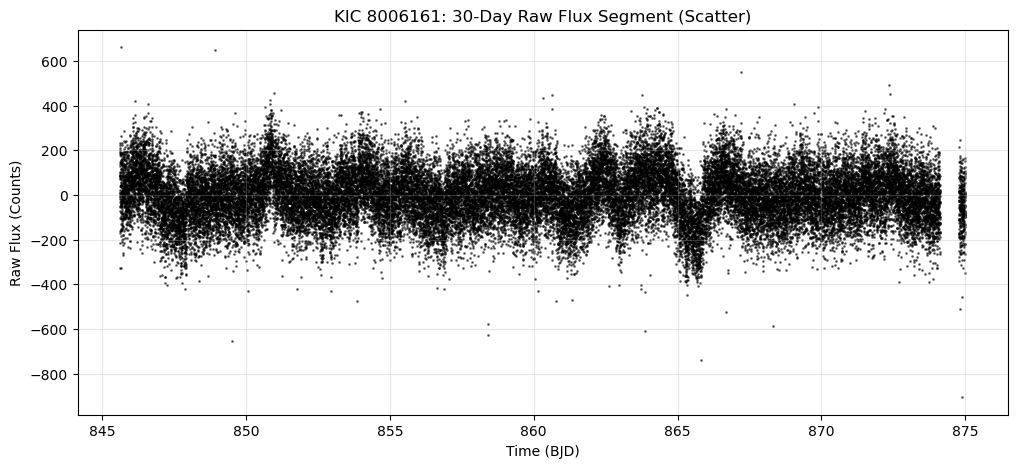

In [19]:
data1 = np.loadtxt(file_path1)
data2 = np.loadtxt(file_path2)
data3 = np.loadtxt(file_path3)
t = data3[:,0]
flux = data3[:,1]

# star 1
t0 = 948
t1 = t0 + 30

# star 2
# t0 = 352
# t1 = t0 + 30

# star 3
t0 = 845
t1 = t0 + 30

mask = (t >= t0) & (t <= t1)

t_30 = t[mask]
flux_30 = flux[mask]

# 5. Scatter Plot
plt.figure(figsize=(12, 5))
plt.scatter(t_30, flux_30, s=1, color='black', alpha=0.5)

plt.title('KIC 8006161: 30-Day Raw Flux Segment (Scatter)')
plt.xlabel('Time (BJD)')
plt.ylabel('Raw Flux (Counts)')
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
ps = psd(ID=None, time=t_30, flux=flux_30)
ps()

freq_new = np.array(ps.freq)
power_new = np.array(ps.powerdensity)

freq_data = np.loadtxt(real_files[2])
freq_old = freq_data[:, 0]
power_old = freq_data[:, 1]

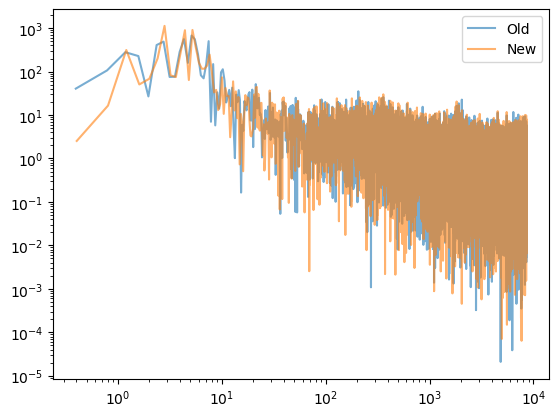

In [21]:
plt.figure()
plt.plot(freq_old, power_old, alpha=0.6, label="Old")
plt.plot(freq_new, power_new, alpha=0.6, label="New")
plt.yscale("log")  # standard for asteroseismic power spectra
plt.xscale("log")
plt.legend()
print("Old df:", freq_old[1] - freq_old[0])
print("New df:", freq_new[1] - freq_new[0])

print("Old max freq:", freq_old.max())
print("New max freq:", freq_new.max())

print("Old mean power:", np.mean(power_old))
print("New mean power:", np.mean(power_new))

In [24]:

# Create a results list for the real stars
real_results = []

# --- Run Fake Signals (Controlled Grid) ---
for i in tqdm(range(len(fake)), desc="Checking False Alarms"):
    detected, diag = run_full_pipeline(freq, fake[i], return_diagnostics=True)
    if detected:
        false_cases.append(diag)

# --- Run Real Signals (Native Grids) ---
print("\n--- Processing Real Stars ---")
for f_native, p_native, name in real_data_list:
    # We pass the NATIVE frequency array for each specific star
    detected, diag = run_full_pipeline(f_native, p_native, return_diagnostics=True)
    
    result_str = "ACCEPTED" if detected else f"REJECTED ({diag['status']})"
    print(f"{name}: {result_str}")
    
    # Store diagnostics for plotting later
    real_results.append((name, detected, diag))

# --- Sanity Check: Recomputed PSD from Lightcurve ---
print("\n--- Sanity Check: Recomputed PSD (30-day masked) ---")

detected_new, diag_new = run_full_pipeline(freq_new, power_new, return_diagnostics=True)

result_str_new = "ACCEPTED" if detected_new else f"REJECTED ({diag_new['status']})"
print(f"Recomputed PSD: {result_str_new}")

# Optional: store separately if you want to inspect later
recomputed_result = (detected_new, diag_new)
print(f"Numax (new PSD): {diag_new.get('numax_est', 'N/A')}")

false_detections = len(false_cases)
print(f"\nFalse detections: {false_detections} / {len(fake)}")
print(f"False alarm rate: {false_detections / len(fake):.3f}")

Checking False Alarms: 100%|██████████| 100/100 [00:09<00:00, 10.35it/s]



--- Processing Real Stars ---
KIC8006161.pow: ACCEPTED
KIC8174981.pow: ACCEPTED
KIC12009504.pow: ACCEPTED

--- Sanity Check: Recomputed PSD (30-day masked) ---
Recomputed PSD: ACCEPTED
Numax (new PSD): 1900.0
Main peak: 0.08234846591949463
Second peak: N/A

False detections: 0 / 100
False alarm rate: 0.000



KIC8006161.pow — νmax Uniqueness
Selected νmax      : 3650.00 μHz
Main peak height   : 1537.012
Second peak height : 1411.085
Peak ratio         : 1.089
Exclusion ±        : 5 grid points


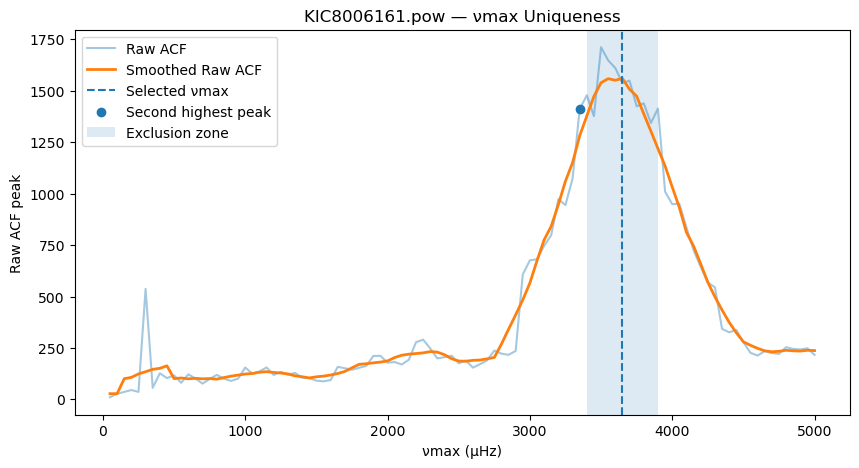


KIC8174981.pow — νmax Uniqueness
Selected νmax      : 1050.00 μHz
Main peak height   : 461.046
Second peak height : 315.009
Peak ratio         : 1.464
Exclusion ±        : 5 grid points


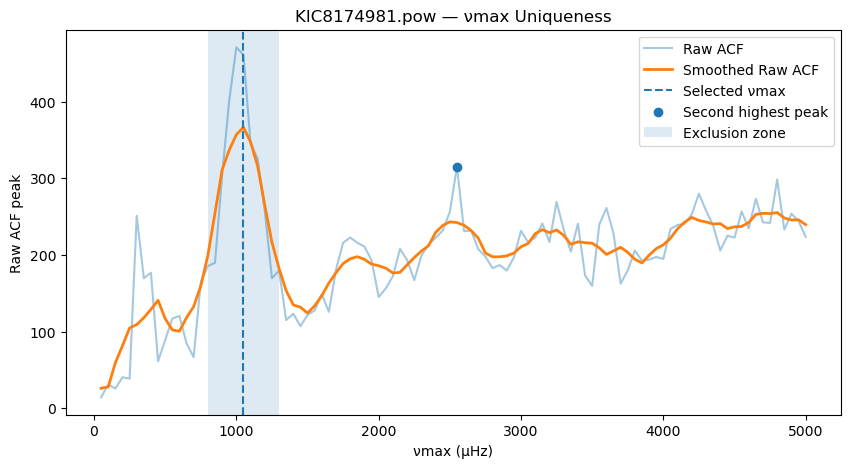


KIC12009504.pow — νmax Uniqueness
Selected νmax      : 1900.00 μHz
Main peak height   : 1016.292
Second peak height : 472.862
Peak ratio         : 2.149
Exclusion ±        : 5 grid points


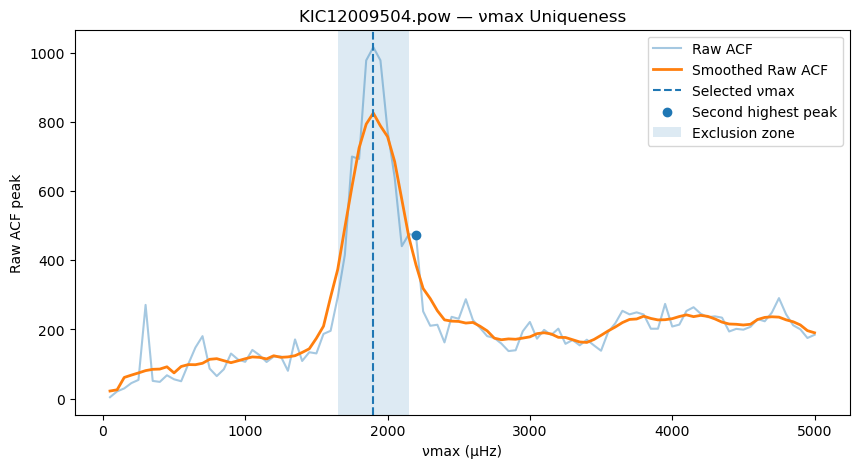


Recomputed PSD — νmax Uniqueness
Selected νmax      : 1900.00 μHz
Main peak height   : 646.505
Second peak height : 510.078
Peak ratio         : 1.267
Exclusion ±        : 5 grid points


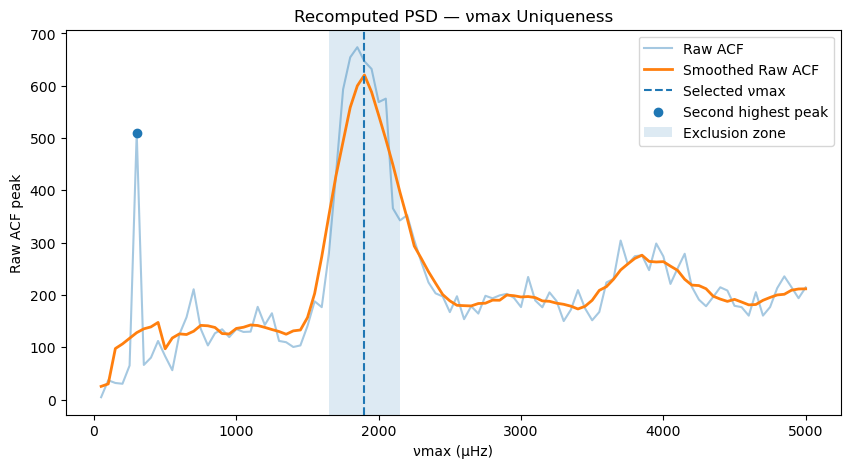

In [25]:
# --- Inspect original accepted star ---
for name, detected, diag in real_results:
    inspect_numax_uniqueness(diag, title=f"{name} — νmax Uniqueness")

# --- Inspect recomputed PSD ---
inspect_numax_uniqueness(diag_new, title="Recomputed PSD — νmax Uniqueness")



OLD Δν Stage
Δν peak height  : 0.096
Contrast        : 4.497
Peak ratio      : 3.208
Exclusion ±     : 6 bins


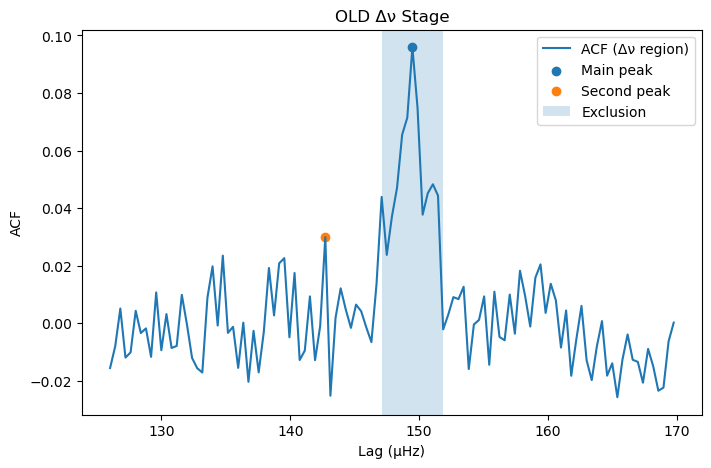


OLD Δν Stage
Δν peak height  : 0.097
Contrast        : 2.015
Peak ratio      : inf
Exclusion ±     : 22 bins


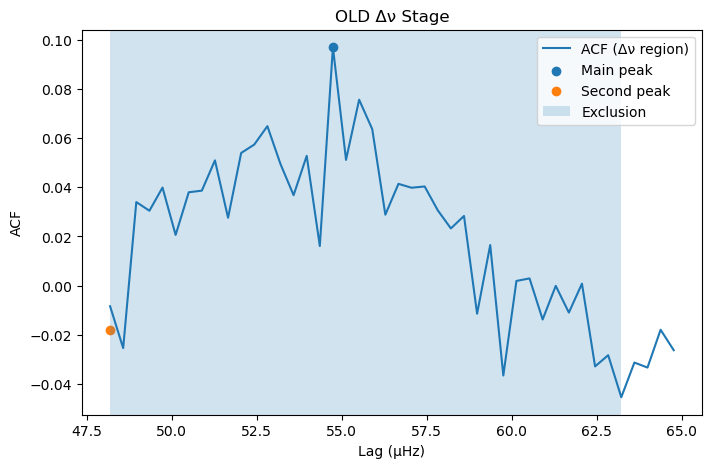


OLD Δν Stage
Δν peak height  : 0.094
Contrast        : 3.060
Peak ratio      : 12.319
Exclusion ±     : 22 bins


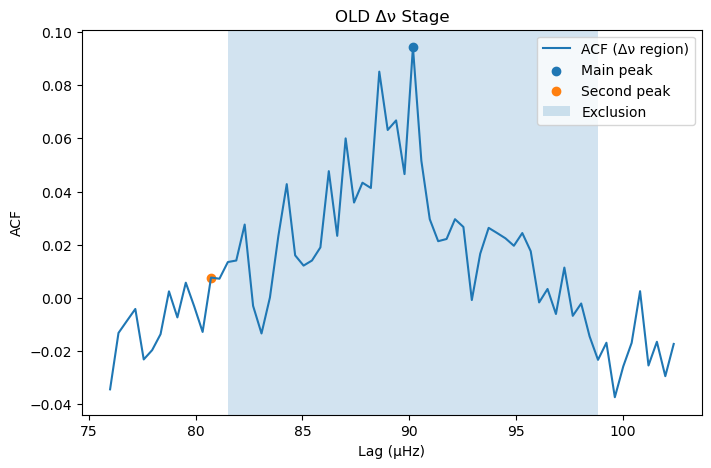


NEW Δν Stage
Δν peak height  : 0.082
Contrast        : 2.940
Peak ratio      : 2.401
Exclusion ±     : 16 bins


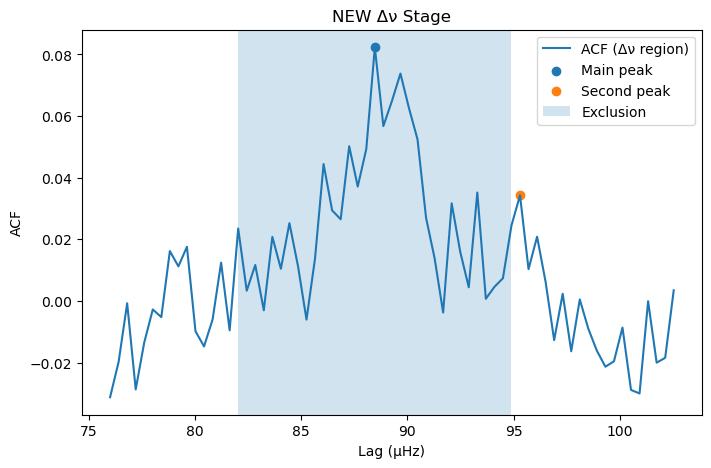

In [26]:
for name, detected, diag in real_results:
    inspect_dnu_stage(diag, "OLD Δν Stage")
inspect_dnu_stage(diag_new, "NEW Δν Stage")


In [33]:
print("\n--- Detailed Comparison ---")

detected_old, diag_old = run_full_pipeline(freq_old, power_old, return_diagnostics=True)

print("Old numax:", diag_old.get("numax_est"))
print("New numax:", diag_new.get("numax_est"))

print("Old SNR:", diag_old.get("snr"))
print("New SNR:", diag_new.get("snr"))

print("Old status:", diag_old.get("status"))
print("New status:", diag_new.get("status"))



--- Detailed Comparison ---
Old numax: 1050.0
New numax: 1050.0
Old SNR: None
New SNR: None
Old status: REJECTED: contrast/ratio
New status: REJECTED: contrast/ratio


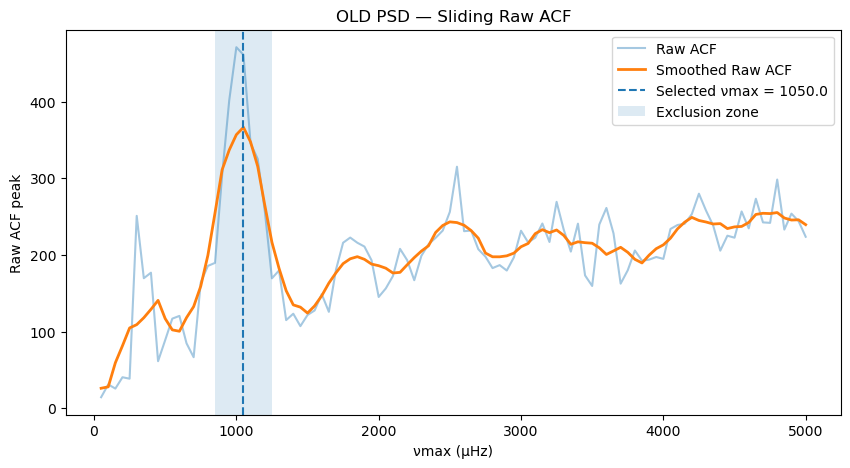

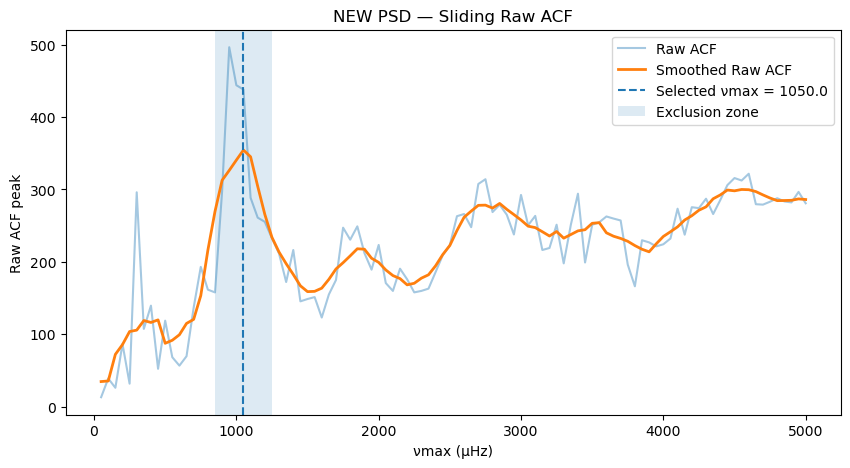

In [34]:
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import numpy as np

# --- Define grid exactly as in pipeline ---
numax_grid = np.linspace(50, 5000, 100)

# --- Prepare flattened spectra (same as pipeline Phase 1) ---
def prepare_flat(freq, power):
    df = freq[1] - freq[0]
    smooth_width_bins = int(600 / df)
    background = uniform_filter1d(power, size=smooth_width_bins)
    return power / background

power_flat_old = prepare_flat(freq_old, power_old)
power_flat_new = prepare_flat(freq_new, power_new)

# --- Run sliding ACF search (ignore SNR output) ---
_, acf_raw_old = sliding_acf_search(freq_old, power_flat_old, numax_grid)
_, acf_raw_new = sliding_acf_search(freq_new, power_flat_new, numax_grid)

# --- Smooth RAW curves (same smoothing as pipeline) ---
smooth_size = 7
acf_raw_old_s = uniform_filter1d(acf_raw_old, size=smooth_size)
acf_raw_new_s = uniform_filter1d(acf_raw_new, size=smooth_size)

# --- Find νmax from smoothed RAW ---
imax_old = np.argmax(acf_raw_old_s)
imax_new = np.argmax(acf_raw_new_s)

numax_old = numax_grid[imax_old]
numax_new = numax_grid[imax_new]

# --- Exclusion zone (must match pipeline) ---
exclude = 4  # same as pipeline

def exclusion_bounds(imax):
    start = max(0, imax - exclude)
    end = min(len(numax_grid) - 1, imax + exclude)
    return numax_grid[start], numax_grid[end]

old_lo, old_hi = exclusion_bounds(imax_old)
new_lo, new_hi = exclusion_bounds(imax_new)

# ============================================================
# Plot OLD
# ============================================================
plt.figure(figsize=(10,5))

plt.plot(numax_grid, acf_raw_old, alpha=0.4, label="Raw ACF")
plt.plot(numax_grid, acf_raw_old_s, linewidth=2, label="Smoothed Raw ACF")

plt.axvline(numax_old, linestyle='--', label=f"Selected νmax = {numax_old:.1f}")

plt.axvspan(old_lo, old_hi, alpha=0.15, label="Exclusion zone")

plt.xlabel("νmax (μHz)")
plt.ylabel("Raw ACF peak")
plt.title("OLD PSD — Sliding Raw ACF")
plt.legend()
plt.show()


# ============================================================
# Plot NEW
# ============================================================
plt.figure(figsize=(10,5))

plt.plot(numax_grid, acf_raw_new, alpha=0.4, label="Raw ACF")
plt.plot(numax_grid, acf_raw_new_s, linewidth=2, label="Smoothed Raw ACF")

plt.axvline(numax_new, linestyle='--', label=f"Selected νmax = {numax_new:.1f}")

plt.axvspan(new_lo, new_hi, alpha=0.15, label="Exclusion zone")

plt.xlabel("νmax (μHz)")
plt.ylabel("Raw ACF peak")
plt.title("NEW PSD — Sliding Raw ACF")
plt.legend()
plt.show()


Analyzing KIC8006161.pow...
Status: ACCEPTED
Contrast: 4.43 (Threshold: 2.0)
Ratio: 3.18 (Threshold: 1.2)
Δν = 149.398 ± 0.330 μHz


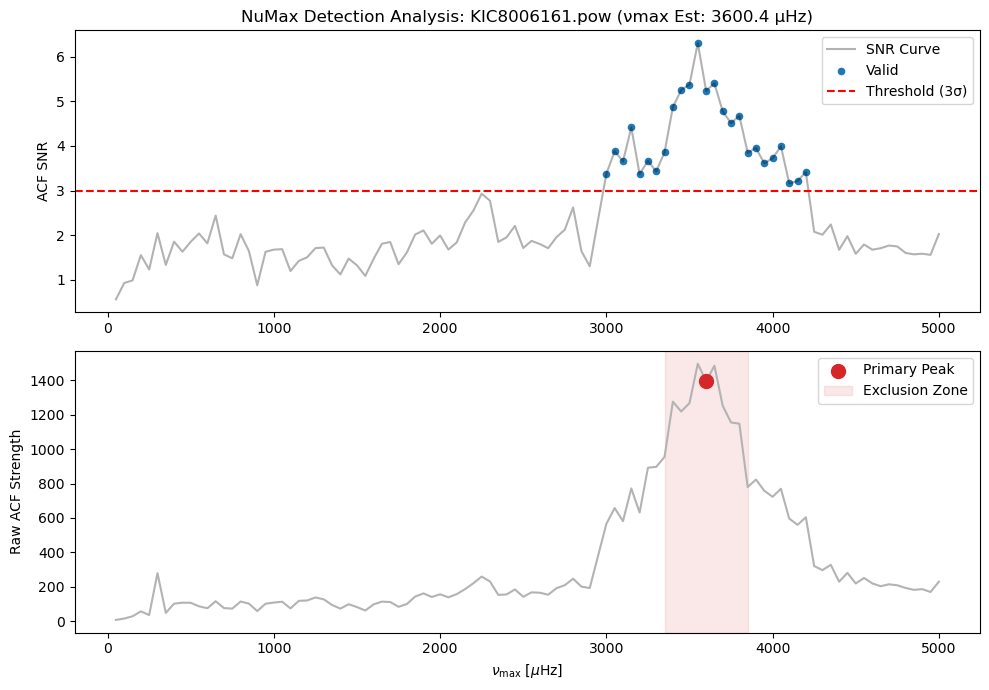

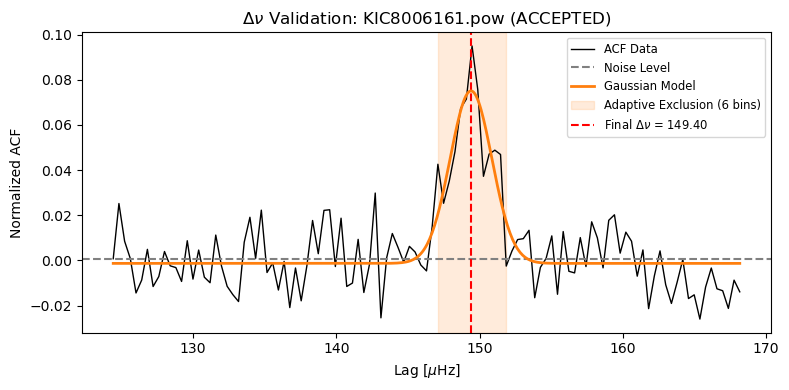

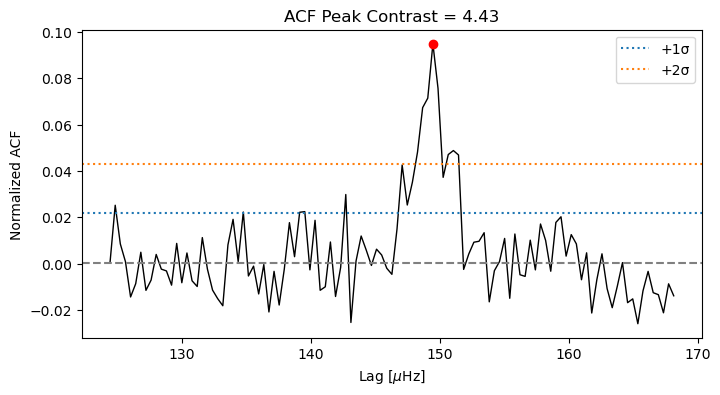

In [23]:
# --- DIAGNOSTIC PLOTTING FOR STAR 3 (KIC12009504) ---
staridx = 0
# Find the diagnostic dictionary for Star 3
# Index 2 corresponds to the 3rd star in your real_files list
star_name, detected, case = real_results[staridx]

print(f"Analyzing {star_name}...")
print(f"Status: {case['status']}")
print(f"Contrast: {case['peak_contrast']:.2f} (Threshold: 2.0)")
print(f"Ratio: {case['peak_ratio']:.2f} (Threshold: 1.2)")
# Assuming 'case' is your dictionary:
print(f"Δν = {case['dnu_final']:.3f} ± {case['popt'][2]/case['peak_contrast']:.3f} μHz") if case['dnu_final'] else print("No detection.")


# --- PLOT 1: NuMax Search Logic ---
plt.figure(figsize=(10, 7))

# Top: SNR of the sliding ACF
plt.subplot(2, 1, 1)
plt.plot(case["numax_grid"], case["acf_snr"], color="black", alpha=0.3, label="SNR Curve")
plt.scatter(case["numax_grid"][case["valid"]], case["acf_snr"][case["valid"]], color="C0", s=20, label="Valid")
plt.axhline(3, ls="--", color="red", label="Threshold (3σ)")
plt.ylabel("ACF SNR")
plt.title(f"NuMax Detection Analysis: {star_name} (νmax Est: {case['numax_est']:.1f} μHz)")
plt.legend()

# Bottom: Raw ACF strength
plt.subplot(2, 1, 2)
plt.plot(case["numax_grid"], case["acf_raw"], color="0.7")
plt.scatter(case["numax_grid"][case["imax"]], case["acf_raw"][case["imax"]], color="C3", s=100, zorder=5, label="Primary Peak")

# Highlight the exclusion zone around the primary peak
exc = case["exclude"]
idx = case["imax"]
plt.axvspan(case["numax_grid"][max(0, idx-exc)], 
            case["numax_grid"][min(len(case["numax_grid"])-1, idx+exc)], 
            color="C3", alpha=0.1, label="Exclusion Zone")

plt.xlabel(r"$\nu_{\max}$ [$\mu$Hz]")
plt.ylabel("Raw ACF Strength")
plt.legend()
plt.tight_layout()
plt.show()

# --- PLOT 2: Dnu Search & Gaussian Fit ---
plt.figure(figsize=(8, 4))
plt.plot(case["lags_fit"], case["acf_fit"], lw=1, color="k", label="ACF Data", zorder=2)
plt.axhline(case["noise_level"], color="grey", ls="--", label="Noise Level")

# 1. Show the Gaussian Fit
if case["popt"] is not None and any(case["popt"]):
    lags_smooth = np.linspace(case["lags_fit"].min(), case["lags_fit"].max(), 500)
    fit_curve = gaussian(lags_smooth, *case["popt"])
    plt.plot(lags_smooth, fit_curve, color="C1", lw=2, label="Gaussian Model", zorder=3)

# 2. Highlight the ADAPTIVE Exclusion Zone
exc = case["exclude_dnu"]
idx = case["imax_dnu"]
lags_fit = case["lags_fit"]

# Calculate the actual lag values for the shading
low_bound = lags_fit[max(0, idx - exc)]
high_bound = lags_fit[min(len(lags_fit) - 1, idx + exc)]

plt.axvspan(low_bound, high_bound, color="C1", alpha=0.15, label=f"Adaptive Exclusion ({exc} bins)")

# 3. Mark the final detection
if case["dnu_final"] is not None:
    plt.axvline(case["dnu_final"], color="r", ls="--", label=rf"Final $\Delta\nu$ = {case['dnu_final']:.2f}")

plt.title(rf"$\Delta\nu$ Validation: {star_name} ({case['status']})")
plt.xlabel(r"Lag [$\mu$Hz]")
plt.ylabel("Normalized ACF")
plt.legend(loc='upper right', fontsize='small')
plt.tight_layout()
plt.show()

# --- PLOT 3: Significance/Contrast ---
plt.figure(figsize=(8, 4))
plt.plot(case["lags_fit"], case["acf_fit"], lw=1, color="k")
nl, ns = case["noise_level"], case["noise_sigma"]
plt.axhline(nl, color="grey", ls="--")
plt.axhline(nl + ns, ls=":", color="C0", label="+1σ")
plt.axhline(nl + 2*ns, ls=":", color="C1", label="+2σ")
plt.plot(case["lags_fit"][np.argmax(case["acf_fit"])], case["peak_main"], "ro")

plt.title(rf"ACF Peak Contrast = {case['peak_contrast']:.2f}")
plt.xlabel(r"Lag [$\mu$Hz]")
plt.ylabel("Normalized ACF")
plt.legend()
plt.show()

Noise Signal Analysis
Status: REJECTED: no SNR peak


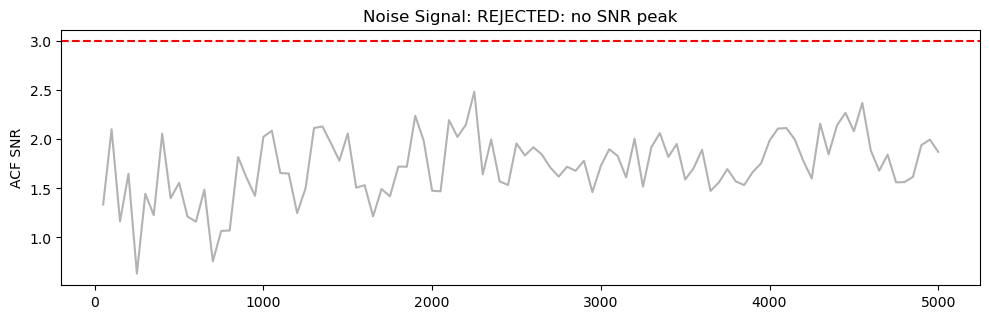

Skipping Δν plot: Pipeline stopped at step: REJECTED: no SNR peak


In [24]:
# --- PLOT DIAGNOSTICS FOR A REJECTED NOISE SIGNAL ---
noise_signal = fake[0]
detected, case = run_full_pipeline(freq, noise_signal, return_diagnostics=True)

print(f"Noise Signal Analysis")
print(f"Status: {case.get('status', 'Unknown')}")

# --- Plot 1: NuMax Search (The first hurdle) ---
plt.figure(figsize=(10, 6))
# Check if NuMax data exists
if "numax_grid" in case and "acf_snr" in case:
    plt.subplot(2, 1, 1)
    plt.plot(case["numax_grid"], case["acf_snr"], color="black", alpha=0.3)
    plt.axhline(3, ls="--", color="red", label="3σ Threshold")
    plt.ylabel("ACF SNR")
    plt.title(f"Noise Signal: {case.get('status')}")

    if "acf_raw" in case:
        plt.subplot(2, 1, 2)
        plt.plot(case["numax_grid"], case["acf_raw"], color="0.7")
        if "imax" in case:
            plt.scatter(case["numax_grid"][case["imax"]], case["acf_raw"][case["imax"]], 
                        color="C3", label="Highest Noise Peak")
        plt.xlabel(r"$\nu_{\max}$ [$\mu$Hz]")
        plt.ylabel("Raw ACF Strength")
        plt.legend()
else:
    print("Signal failed so early that even NuMax grid data is missing.")

plt.tight_layout()
plt.show()

# --- Plot 2: Delta Nu Search (The second hurdle) ---
# Only attempt to plot if the code actually performed the Dnu search
if "lags_fit" in case and "acf_fit" in case:
    plt.figure(figsize=(8, 4))
    plt.plot(case["lags_fit"], case["acf_fit"], lw=1, color="k", label="Noise ACF")
    
    # Safely get Dnu parameters
    exc = case.get("exclude_dnu", 5)
    idx = case.get("imax_dnu", 0)
    lags_fit = case["lags_fit"]
    
    # Highlight exclusion zone
    if idx < len(lags_fit):
        low_b = lags_fit[max(0, idx - exc)]
        high_b = lags_fit[min(len(lags_fit) - 1, idx + exc)]
        plt.axvspan(low_b, high_b, color="gray", alpha=0.2, label="Exclusion Zone")

    # Show the Gaussian fit if it was attempted
    popt = case.get("popt")
    if popt is not None and any(popt):
        lags_smooth = np.linspace(lags_fit.min(), lags_fit.max(), 500)
        plt.plot(lags_smooth, gaussian(lags_smooth, *popt), color="C1", ls="--", label="Failed/Poor Fit")

    contrast = case.get('peak_contrast', 0.0)
    plt.title(f"ACF of Noise (Contrast: {contrast:.2f})")
    plt.xlabel(r"Lag [$\mu$Hz]")
    plt.ylabel("Normalized ACF")
    plt.legend()
    plt.show()
else:
    print(f"Skipping Δν plot: Pipeline stopped at step: {case.get('status')}")